<a href="https://colab.research.google.com/github/ran031027/lv-bag-resale-analysis/blob/main/lv-bag-resale-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 【データ分析】フリマアプリにおけるルイ・ヴィトンの適正価格・リセール傾向の可視化

このノートブックでは、ルイ・ヴィトンの中古バッグデータを用いて、モデルや状態ランク、素材（ライン）ごとの価格・流通傾向を分析しています。  
単なる価格集計にとどまらず、**出品者の適正価格設定の支援**や**高価格帯アイテムの取引促進**に向けたデータドリブンな考察・施策提言を行っています。

分析内容の例：
- モデル別の平均価格とリセールバリューの違い
- 状態ランク（S / A / B）による価格分布の差
- ライン（Monogram / Damier / Epi など）ごとの価格帯・人気傾向


In [17]:
!pip install japanize-matplotlib


In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 先にスタイルを適用
plt.style.use('seaborn-v0_8-whitegrid')

# 最後に日本語フォントを有効化
import japanize_matplotlib


データの整形が完了しました！
     商品ID           ブランド             商品名           ライン    カラー 状態      価格 在庫数  \
0  LV0001  Louis Vuitton       Speedy 25      Monogram  Brown  A   98000   1   
1  LV0002  Louis Vuitton    Neverfull MM  Damier Ebene  Brown  S  178000   2   
2  LV0003  Louis Vuitton         Alma BB           Epi  Black  A  165000   1   
3  LV0004  Louis Vuitton  Pochette Métis      Monogram  Brown  B  192000   1   
4  LV0005  Louis Vuitton      Keepall 45      Monogram  Brown  B  158000   1   

    製造年         登録日  
0  2021  2026-07-01  
1  2024  2026-07-01  
2  2023  2026-07-02  
3  2022  2026-07-02  
4  2020  2026-07-03  


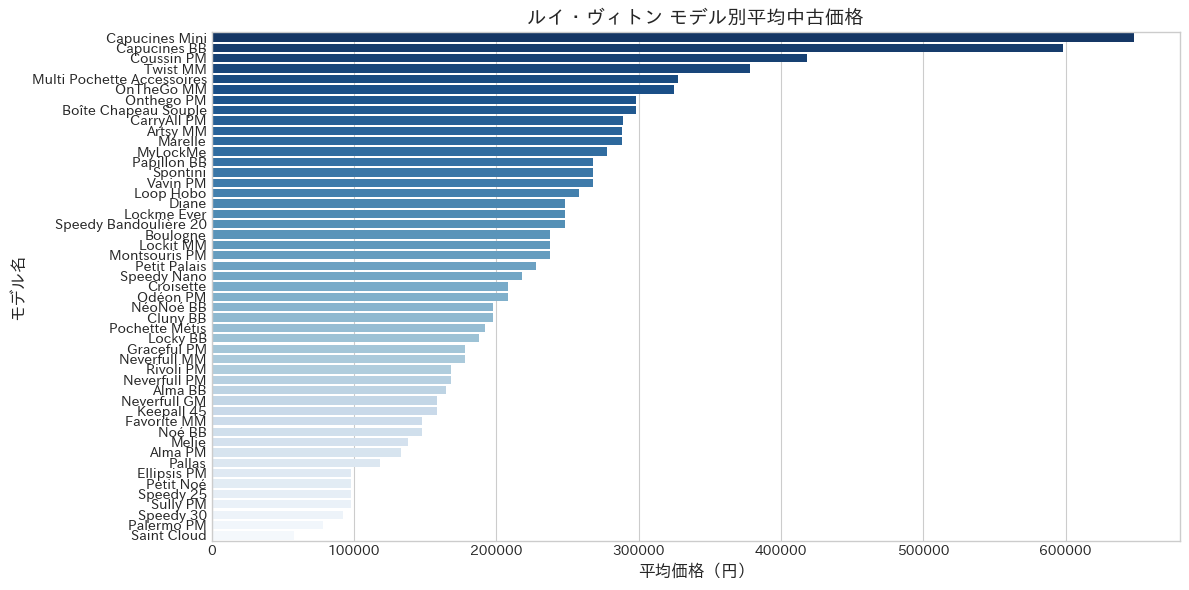

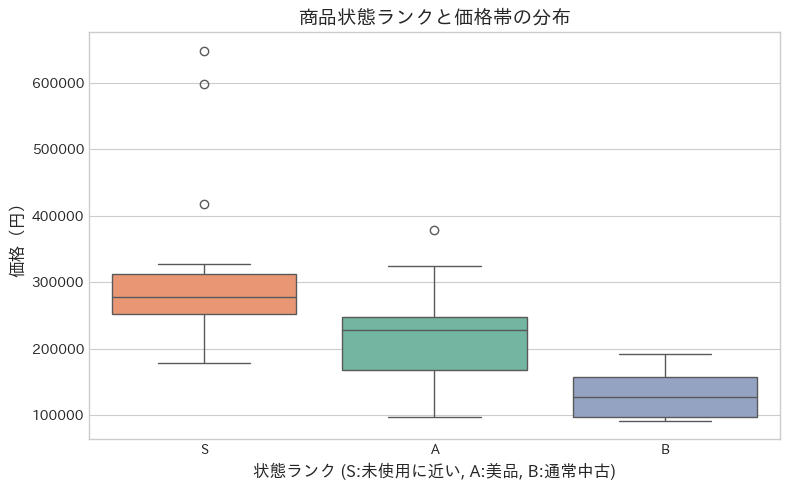

In [20]:
# 必要なライブラリのインポート
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語フォントを有効化

# 1. データの読み込みと整形
# csvがexcel形式で保存されている場合は read_csv または sep=',' を指定して読み込みます
try:
    df = pd.read_csv('lv_bags.csv.xlsx')
except Exception:
    # 万が一Excelとして1列に入っている場合の手動パース（余分な空白を除去）
    df_raw = pd.read_excel('lv_bags.csv.xlsx')
    col_name = df_raw.columns[0]
    headers = [h.strip() for h in col_name.split(',')]
    data_rows = [[str(v).strip() for v in str(val).split(',')] for val in df_raw[col_name]]
    df = pd.DataFrame(data_rows, columns=headers)

# 数値データの型変換と不要な空白の除去
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

df['価格'] = pd.to_numeric(df['価格'], errors='coerce').fillna(0).astype(int)
df['製造年'] = pd.to_numeric(df['製造年'], errors='coerce').fillna(0).astype(int)

print("データの整形が完了しました！")
print(df.head())

# 2. グラフ描画スタイルの設定
plt.style.use('seaborn-v0_8-whitegrid')
japanize_matplotlib.japanize()  # スタイル設定後に日本語化を適用

# --- Graph 1. モデル別平均中古価格 ---
plt.figure(figsize=(12, 6))
model_price = df.groupby('商品名')['価格'].mean().sort_values(ascending=False)

sns.barplot(
    x=model_price.values,
    y=model_price.index,
    hue=model_price.index,
    palette='Blues_r',
    legend=False
)

plt.title('ルイ・ヴィトン モデル別平均中古価格', fontsize=14)
plt.xlabel('平均価格（円）', fontsize=12)
plt.ylabel('モデル名', fontsize=12)
plt.tight_layout()
plt.savefig('model_price_analysis.png')
plt.show()

# --- Graph 2. 商品状態ランクと価格帯の分布 ---
plt.figure(figsize=(8, 5))
condition_order = ['S', 'A', 'B']  # 美品〜通常中古

sns.boxplot(
    data=df,
    x='状態',
    y='価格',
    order=condition_order,
    hue='状態',        # ★ paletteを使用する際は hue を指定
    palette='Set2',
    legend=False      # ★ 凡例を非表示
)

plt.title('商品状態ランクと価格帯の分布', fontsize=14)
plt.xlabel('状態ランク (S:未使用に近い, A:美品, B:通常中古)', fontsize=12)
plt.ylabel('価格（円）', fontsize=12)
plt.tight_layout()
plt.savefig('condition_price_analysis.png')
plt.show()

### モデル別価格の考察

Capucines BB や OnTheGo MM などの高価格帯モデルは、中古市場でも 30〜50 万円以上の高い価格帯を維持している傾向が見られる。一方、Speedy 25 や Noé BB のような定番モデルは 10 万円前後に分布しており、価格は比較的手頃だが、その分フリマアプリ等での取引ボリュームが非常に多いモデルであると推測できる。


### 状態ランク別価格の考察

状態ランク S（未使用に近い）と A・B の間には明確な価格差が存在する。特にハイエンドモデルほど状態の影響を受けやすく、S から A・B へとランクが落ちる際の価格下落幅が大きい傾向がある。これは「高価格帯モデルほど、購入者が状態にシビアである」ことを示しており、仕入れや価格戦略を考える際の重要なポイントとなる。


## 施策提案：経年減価（型落ち）の自動シミュレーター

### 課題
ブランド品は「いつ売るか」で価格が大きく変わるが、現状の出品者行動は  
「もう使わないけど、いつか売ればいいか」という先送りが多く、  
クローゼットの中に眠る“隠れ資産”が大量に存在している。

### 施策内容
過去の購入履歴や持ち物リスト（「めざまし出品」「持ち物自動登録」など）に登録されている  
ルイ・ヴィトンのバッグに対して、

> 「このスピーディは 1 年後にさらに〇%（約〇万円）相場が落ちる見込みです。  
> 今売るのが最もお得です！」

といった **価格下落アラート（売却タイミング最大化シミュレーター）** を自動配信する機能を提供する。

- モデル別・状態別・製造年別の過去相場から「将来の期待価格カーブ」を推計
- ユーザーの保有アイテムに対して「今売る vs 1年後売る」の想定差額を算出
- アプリ内通知・メール・LINE 等で「今が売りどき」をレコメンド

### ビジネス効果
- クローゼットに眠るブランド品という **隠れ資産の出品を掘り起こし**、  
  プラットフォーム全体の出品数・在庫量を大幅に増加させる。
- 「いつ売ればいいかわからない」という心理的ハードルを下げることで、  
  出品までのリードタイムを短縮し、取引回転率の向上が期待できる。
- 将来的には、他ブランドやカテゴリー（時計・ジュエリーなど）にも横展開可能な  
  「価格劣化シミュレーション基盤」として発展させられる。
